In [ ]:
! pip install pytorch-lightning
! pip install torchview

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.6/831.6 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 35.7 MB/s eta 0:00:00


#Loading the plant-type dataset

In [ ]:
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
import os
import kagglehub


print("Downloading Kaggle dataset...")
# Download the dataset
path = kagglehub.dataset_download("yudhaislamisulistya/plants-type-datasets")
print(f"Dataset downloaded to: {path}")

# --- 1. DATA PREPARATION ---

# Define paths
data_dir = os.path.join(path, 'split_ttv_dataset_type_of_plants')
train_dir = os.path.join(data_dir, 'Train_Set_Folder')
val_dir = os.path.join(data_dir, 'Validation_Set_Folder')
test_dir = os.path.join(data_dir, 'Test_Set_Folder')

# Check if directories exist
if not os.path.exists(train_dir):
    print(f"Error: Training directory not found at {train_dir}")
else:
    print("Dataset paths verified.")

# Define image size and batch size
IMG_SIZE = 128
BATCH_SIZE = 64

# Define transforms
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

# Training transforms with augmentation
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

# Validation and test transforms
val_test_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

# Create datasets using ImageFolder
train_dataset = torchvision.datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset = torchvision.datasets.ImageFolder(val_dir, transform=val_test_transform)
test_dataset = torchvision.datasets.ImageFolder(test_dir, transform=val_test_transform)

#Create DataLoaders
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, num_workers=2)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, num_workers=2)

#Get class info
class_names = train_dataset.classes
num_classes = len(class_names)

print(f"Data loaded.")
print(f"Number of classes: {num_classes}")
print(f"Training data size: {len(train_dataset)}")
print(f"Validation data size: {len(val_dataset)}")
print(f"Test data size: {len(test_dataset)}")




Using Colab cache for faster access to the 'plants-type-datasets' dataset.
Dataset downloaded to: /kaggle/input/plants-type-datasets
Dataset paths verified.
Data loaded.
Number of classes: 30
Training data size: 23972
Validation data size: 3030
Test data size: 2998


#Model

In [ ]:
import torch.nn as nn
import pytorch_lightning as pl



class FineTuneEfficientNetB0(nn.Module):
    """
    An EfficientNet-B0 model for fine-tuning.

    """
    def __init__(self, num_classes):
        super().__init__()

        self.model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)


        num_features = self.model.classifier[1].in_features

        self.model.classifier[1] = nn.Linear(num_features, num_classes)

    def forward(self, x):
        return self.model(x)

print(f"\nDefined FineTuneEfficientNetB0 model class.")




class FineTuneLightningModule(pl.LightningModule):
    """
    PyTorch Lightning Module for fine-tuning.
    This module is now generic and accepts a model class.
    """
    def __init__(self, model_class, num_classes, learning_rate=1e-4):
        super().__init__()
        # Save hyperparameters
        self.save_hyperparameters('num_classes', 'learning_rate')

        # Instantiate the model from the passed class
        self.model = model_class(num_classes)
        self.criterion = nn.CrossEntropyLoss()

        # Metrics
        task = "multiclass"
        self.train_acc = torchmetrics.Accuracy(task=task, num_classes=num_classes)
        self.val_acc = torchmetrics.Accuracy(task=task, num_classes=num_classes)
        self.test_acc = torchmetrics.Accuracy(task=task, num_classes=num_classes)
        self.test_precision = torchmetrics.Precision(task=task, num_classes=num_classes, average='macro')
        self.test_recall = torchmetrics.Recall(task=task, num_classes=num_classes, average='macro')
        self.test_f1 = torchmetrics.F1Score(task=task, num_classes=num_classes, average='macro')
        self.test_confmat = torchmetrics.ConfusionMatrix(task=task, num_classes=num_classes)

        # For evaluation
        self.test_preds = []
        self.test_labels = []

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self.model(images)
        loss = self.criterion(outputs, labels)
        self.log('train_loss', loss, on_step=True, on_epoch=True, prog_bar=True)
        self.log('train_acc', self.train_acc(outputs, labels), on_step=True, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self.model(images)
        loss = self.criterion(outputs, labels)
        self.log('val_loss', loss, on_epoch=True, prog_bar=True)
        self.log('val_acc', self.val_acc(outputs, labels), on_epoch=True, prog_bar=True)
        return loss

    def test_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self.model(images)
        loss = self.criterion(outputs, labels)
        preds = torch.argmax(outputs, dim=1)

        # Log metrics
        self.log('test_loss', loss, on_epoch=True)
        self.log('test_acc', self.test_acc(outputs, labels), on_epoch=True)
        self.log('test_precision', self.test_precision(preds, labels), on_epoch=True)
        self.log('test_recall', self.test_recall(preds, labels), on_epoch=True)
        self.log('test_f1', self.test_f1(preds, labels), on_epoch=True)

        # Save preds and labels for confusion matrix
        self.test_confmat.update(preds, labels)
        self.test_preds.append(preds.cpu())
        self.test_labels.append(labels.cpu())

    def configure_optimizers(self):
        optimizer = optim.Adam(self.model.parameters(), lr=self.hparams.learning_rate)

        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=0.1,
            patience=3,
        )
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_loss",
                "interval": "epoch",
                "frequency": 1
            }
        }


Defined FineTuneEfficientNetB0 model class.


In [ ]:
!pip install -q langchain langchain-openai langchain-community pydantic torch torchvision pytorch-lightning lancedb langchain-text-splitters beautifulsoup4 tiktoken

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.0/76.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.2/39.2 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.6/48.6 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.6/229.6 kB 18.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


In [ ]:
#API
os.environ["OPENAI_API_KEY"] = ""


In [ ]:
import lancedb
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import LanceDB
from langchain_openai import OpenAIEmbeddings

urls = {
    "aloevera": "https://www.almanac.com/plant/aloe-vera",
    "banana": "https://www.thespruce.com/banana-tree-growing-profile-3269353",
    "cucumber": "https://www.almanac.com/plant/cucumbers",
    "ginger": "https://www.almanac.com/plant/ginger",
    "spinach": "https://www.almanac.com/plant/spinach"
}

# --- 2. LOAD DOCUMENTS ---
print("🕷️ Scraping plant care guides...")
docs = []
for plant, url in urls.items():
    print(f"   - Loading {plant} from {url}...")
    loader = WebBaseLoader(url)
    loaded_docs = loader.load()
    for d in loaded_docs:
        d.metadata["plant_type"] = plant
    docs.extend(loaded_docs)

# --- 3. SPLIT DOCUMENTS ---
print(f"✂️ Splitting {len(docs)} documents into chunks...")
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
    separators=["\n\n", "\n", ".", "!", "?", ",", " "]
)
splits = text_splitter.split_documents(docs)
print(f"   - Created {len(splits)} chunks.")

# --- 4. CREATE VECTOR STORE (LanceDB) ---
print("💾 Building LanceDB Vector Store...")

# 1. Clean up previous DB
!rm -rf /tmp/lancedb_plants

# 2. Connect to the DB folder
db = lancedb.connect("/tmp/lancedb_plants")

# 3. Initialize Embeddings
embeddings = OpenAIEmbeddings()

# 4. Create Vector Store (Let LangChain create the table for you)
vector_store = LanceDB.from_documents(
    documents=splits,
    embedding=embeddings,
    connection=db,
    table_name="plant_knowledge"
)

print("✅ Knowledge Base Ready!")

🕷️ Scraping plant care guides...
   - Loading aloevera from https://www.almanac.com/plant/aloe-vera...
   - Loading banana from https://www.thespruce.com/banana-tree-growing-profile-3269353...
   - Loading cucumber from https://www.almanac.com/plant/cucumbers...
   - Loading ginger from https://www.almanac.com/plant/ginger...
   - Loading spinach from https://www.almanac.com/plant/spinach...
✂️ Splitting 5 documents into chunks...
   - Created 24 chunks.
💾 Building LanceDB Vector Store...
✅ Knowledge Base Ready!


In [ ]:
import json
import os
from PIL import Image as PILImage

# --- PyTorch & Lightning Imports ---
import torch
import torch.nn as nn
import torch.optim as optim
import pytorch_lightning as pl
from torchvision import models, transforms
import torchmetrics

# --- Pydantic Imports ---
from pydantic import BaseModel, Field
from typing import Optional, List
from google.colab import drive

# --- LangChain Imports ---
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate


drive.mount('/content/drive')

class PlantCareCard(BaseModel):
    """
    A structured data card containing essential care information for a plant.
    """
    common_name: str = Field(description="The common name(s) of the plant (e.g., 'Snake Plant', 'Mother-in-Law's Tongue').")
    description: str = Field(description="A brief, one or two-sentence description of the plant.")

    # --- Care Instructions ---
    lighting: str = Field(description="Lighting conditions (e.g., 'Bright, indirect light', 'Tolerates low light', 'Full sun').")
    watering: str = Field(description="Watering instructions (e.g., 'Water every 2-3 weeks, allow soil to dry out completely').")
    temperature: str = Field(description="Ideal temperature range (e.g., '18°C - 29°C').")
    soil: str = Field(description="Recommended soil type (e.g., 'Well-draining cactus or succulent mix').")
    fertilizer: str = Field(description="Fertilizing schedule (e.g., 'Feed with a balanced liquid fertilizer monthly during spring and summer').")


    outdoors: bool = Field(description="A boolean (True/False) indicating if the plant can typically be kept outdoors (e.g., in a pot during summer).")
    toxicity: Optional[str] = Field(default="N/A", description="Toxicity information, especially for pets and humans (e.g., 'Mildly toxic to cats and dogs if ingested').")

# --- Configuration ---
NUM_CLASSES = num_classes
MODEL_NAME = "EfficientNet_B0_v1"
CHECKPOINT_PATH = f'/content/drive/MyDrive/Colab_Models/{MODEL_NAME}/best-{MODEL_NAME}-model.ckpt'


CLASS_NAMES = [
    "Aloe Vera", "Banana", "Bilimbi", "Cantaloupe", "Cassava",
    "Coconut", "Corn", "Cucumber", "Curcuma", "Eggplant",
    "Galangal", "Ginger", "Guava", "Kale", "Longbeans",
    "Mango", "Melon", "Orange", "Paddy", "Papaya",
    "Pepper Chili", "Pineapple", "Pomelo", "Shallot", "Soybeans",
    "Spinach", "Sweet Potatoes", "Tobacco", "Water Apple", "Watermelon"
]

# ---  Image Transforms ---

inference_transform = transforms.Compose([
    transforms.Resize((224, 224)), # EfficientNet-B0 default
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# --- Model Loading Function ---
def load_model(checkpoint_path, model_class, lightning_class, num_classes):
    """Loads the trained model from a checkpoint."""
    print(f"Attempting to load model from {checkpoint_path}...")
    if not os.path.exists(checkpoint_path):
        print(f"---! ERROR: Checkpoint file not found at {checkpoint_path}")
        print("---! Please train your model first or check the file path.")
        return None

    try:
        trained_model = lightning_class.load_from_checkpoint(
            checkpoint_path,
            model_class=model_class,
            num_classes=num_classes
        )
        trained_model.eval() # Set to evaluation mode
        print("✅ Model loaded successfully!")
        return trained_model
    except Exception as e:
        print(f"---! ERROR loading model: {e}")
        return None

# --- Inference Function ---
def get_plant_label_from_image(image_path: str, model, class_names: List[str], transform) -> str:
    """
    Loads an image, transforms it, and returns the
    predicted plant label from your trained model.
    """
    if not model:
        return "Error: Model not loaded"

    if not os.path.exists(image_path):
        return f"Error: Image file not found at {image_path}"


    # Automatically get the device (CPU or GPU) from the model itself
    device = next(model.parameters()).device

    try:
        img = PILImage.open(image_path).convert("RGB")
        img_tensor = transform(img).unsqueeze(0) # Add batch dimension


        # Move the image tensor to the same device as the model
        img_tensor = img_tensor.to(device)

        with torch.no_grad():
            logits = model(img_tensor)
            pred_idx = torch.argmax(logits, dim=1).item()

        label = class_names[pred_idx]
        print(f"🤖 [Model]: Classified '{image_path}' as: '{label}'")
        return label

    except Exception as e:
        print(f"---! ERROR classifying image: {e}")
        return "Error"


# PART 4: PLANT CARE CARD GENERATOR

def create_rag_plant_care_pipeline():
    """
    Creates the RAG-Augmented LangChain pipeline.
    """
    print("Initializing RAG LLM pipeline...")

    llm = ChatOpenAI(model="gpt-4o", temperature=0)
    structured_llm = llm.with_structured_output(PlantCareCard)

    # --- UPDATED PROMPT WITH CONTEXT ---
    care_card_prompt = ChatPromptTemplate.from_messages([
        ("system",
         """You are a world-class botanist.
         Answer the user's request using the provided Context.

         Context:
         {context}

         Based ONLY on the context above (and your general knowledge if the context is missing specific details),
         generate a comprehensive care card.
         You MUST format your response STRICTLY as the 'PlantCareCard' JSON schema.
         """),
        ("human", "Generate a plant care card for: {plant_name}")
    ])

    rag_chain = care_card_prompt | structured_llm

    print("✅ RAG pipeline created!")
    return rag_chain

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Attempting to load model from /content/drive/MyDrive/Colab_Models/EfficientNet_B0_v1/best-EfficientNet_B0_v1-model.ckpt...
✅ Model loaded successfully!
Initializing RAG LLM pipeline...
✅ RAG pipeline created!

--- 🚀 Processing: /kaggle/input/plants-type-datasets/split_ttv_dataset_type_of_plants/Test_Set_Folder/aloevera/aloevera49.jpg ---


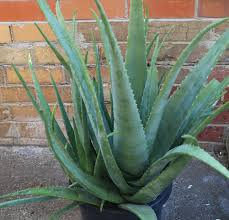

🤖 [Model]: Classified '/kaggle/input/plants-type-datasets/split_ttv_dataset_type_of_plants/Test_Set_Folder/aloevera/aloevera49.jpg' as: 'Aloe Vera'

🔍 [RAG]: Searching knowledge base for 'Aloe Vera'...
   - Found 3 relevant text chunks.

   📄 [Chunk 1]:
   Source: https://www.thespruce.com/banana-tree-growing-profile-3269353

   📄 [Chunk 2]:
   Source: https://www.thespruce.com/banana-tree-growing-profile-3269353

   📄 [Chunk 3]:
   Source: https://www.thespruce.com/banana-tree-growing-profile-3269353
🧠 [Agent]: Generating Augmented Care Card...

--- ✅ FINAL RAG OUTPUT (Aloe Vera) ---
{
  "common_name": "Aloe Vera",
  "description": "Aloe Vera is a succulent plant known for its medicinal properties and easy care, featuring thick, fleshy leaves filled with a soothing gel.",
  "lighting": "Bright, indirect light",
  "watering": "Water every 3 weeks, allowing soil to dry out completely between waterings",
  "temperature": "13\u00b0C - 27\u00b0C",
  "soil": "Well-draining cactus or succule

/tmp/ipython-input-1241976882.py:75: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  print(json.dumps(care_card.dict(), indent=2))


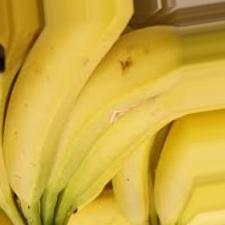

🤖 [Model]: Classified '/kaggle/input/plants-type-datasets/split_ttv_dataset_type_of_plants/Test_Set_Folder/banana/aug_0_5300.jpg' as: 'Banana'

🔍 [RAG]: Searching knowledge base for 'Banana'...
   - Found 3 relevant text chunks.

   📄 [Chunk 1]:
   Source: https://www.thespruce.com/banana-tree-growing-profile-3269353

   📄 [Chunk 2]:
   Source: https://www.thespruce.com/banana-tree-growing-profile-3269353

   📄 [Chunk 3]:
   Source: https://www.thespruce.com/banana-tree-growing-profile-3269353
🧠 [Agent]: Generating Augmented Care Card...

--- ✅ FINAL RAG OUTPUT (Banana) ---
{
  "common_name": "Banana tree, plantain tree",
  "description": "Banana trees are large herbaceous plants known for their fleshy stalks and large, bright green leaves. They produce showy flowers and elongated fruit.",
  "lighting": "Full sun to partial shade",
  "watering": "Water frequently to keep the soil evenly moist but not soggy",
  "temperature": "Hardiness Zones 9\u201311",
  "soil": "Loamy, well-drained s

/tmp/ipython-input-1241976882.py:75: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  print(json.dumps(care_card.dict(), indent=2))


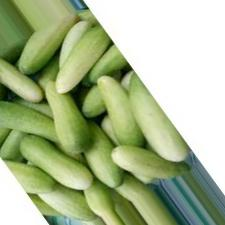

🤖 [Model]: Classified '/kaggle/input/plants-type-datasets/split_ttv_dataset_type_of_plants/Test_Set_Folder/cucumber/aug_0_9533.jpg' as: 'Cucumber'

🔍 [RAG]: Searching knowledge base for 'Cucumber'...
   - Found 3 relevant text chunks.

   📄 [Chunk 1]:
   Source: https://www.thespruce.com/banana-tree-growing-profile-3269353

   📄 [Chunk 2]:
   Source: https://www.thespruce.com/banana-tree-growing-profile-3269353

   📄 [Chunk 3]:
   Source: https://www.thespruce.com/banana-tree-growing-profile-3269353
🧠 [Agent]: Generating Augmented Care Card...

--- ✅ FINAL RAG OUTPUT (Cucumber) ---
{
  "common_name": "Cucumber",
  "description": "Cucumbers are fast-growing, vining plants that produce crisp, refreshing fruits commonly used in salads and pickling.",
  "lighting": "Full sun",
  "watering": "Water consistently to keep the soil evenly moist, especially during dry spells.",
  "temperature": "18\u00b0C - 30\u00b0C",
  "soil": "Well-draining, fertile soil with plenty of organic matter",
  "fer

/tmp/ipython-input-1241976882.py:75: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  print(json.dumps(care_card.dict(), indent=2))


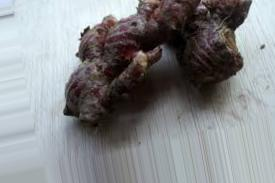

🤖 [Model]: Classified '/kaggle/input/plants-type-datasets/split_ttv_dataset_type_of_plants/Test_Set_Folder/ginger/aug_0_8567.jpg' as: 'Ginger'

🔍 [RAG]: Searching knowledge base for 'Ginger'...
   - Found 3 relevant text chunks.

   📄 [Chunk 1]:
   Source: https://www.almanac.com/plant/aloe-vera

   📄 [Chunk 2]:
   Source: https://www.almanac.com/plant/cucumbers

   📄 [Chunk 3]:
   Source: https://www.almanac.com/plant/ginger
🧠 [Agent]: Generating Augmented Care Card...

--- ✅ FINAL RAG OUTPUT (Ginger) ---
{
  "common_name": "Ginger",
  "description": "Ginger is a tropical flowering plant known for its aromatic rhizomes, which are commonly used as a spice and in traditional medicine.",
  "lighting": "Partial shade to full sun",
  "watering": "Keep soil consistently moist but not waterlogged",
  "temperature": "20\u00b0C - 30\u00b0C",
  "soil": "Rich, well-draining soil with plenty of organic matter",
  "fertilizer": "Feed with a balanced liquid fertilizer every 4-6 weeks during the gro

/tmp/ipython-input-1241976882.py:75: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  print(json.dumps(care_card.dict(), indent=2))


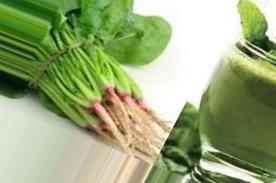

🤖 [Model]: Classified '/kaggle/input/plants-type-datasets/split_ttv_dataset_type_of_plants/Test_Set_Folder/spinach/aug_0_4797.jpg' as: 'Spinach'

🔍 [RAG]: Searching knowledge base for 'Spinach'...
   - Found 3 relevant text chunks.

   📄 [Chunk 1]:
   Source: https://www.thespruce.com/banana-tree-growing-profile-3269353

   📄 [Chunk 2]:
   Source: https://www.thespruce.com/banana-tree-growing-profile-3269353

   📄 [Chunk 3]:
   Source: https://www.thespruce.com/banana-tree-growing-profile-3269353
🧠 [Agent]: Generating Augmented Care Card...

--- ✅ FINAL RAG OUTPUT (Spinach) ---
{
  "common_name": "Spinach",
  "description": "Spinach is a leafy green flowering plant known for its edible leaves, which are rich in iron and vitamins.",
  "lighting": "Full sun to partial shade",
  "watering": "Keep soil consistently moist but not waterlogged",
  "temperature": "10\u00b0C - 24\u00b0C",
  "soil": "Well-draining, fertile soil rich in organic matter",
  "fertilizer": "Apply a balanced fertilize

/tmp/ipython-input-1241976882.py:75: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  print(json.dumps(care_card.dict(), indent=2))


In [ ]:
import glob
import random
from IPython.display import Image, display

img_index = random.randint(0, 98)

if __name__ == "__main__":

    # 1. Load Vision Model
    model = load_model(
        CHECKPOINT_PATH,
        FineTuneEfficientNetB0,
        FineTuneLightningModule,
        NUM_CLASSES
    )

    # 2. Initialize RAG Chain
    rag_chain = create_rag_plant_care_pipeline()

    # 3. Setup Retriever tool
    retriever = vector_store.as_retriever(search_kwargs={"k": 3})

    BASE_TEST_PATH = "/kaggle/input/plants-type-datasets/split_ttv_dataset_type_of_plants/Test_Set_Folder/"

    # Images to test (Filtering for ones we scraped data for)
    supported_plants = ["aloevera", "banana", "cucumber", "ginger", "spinach"]

    # Find test images
    test_image_paths = []
    for plant_class in supported_plants:
        class_folder = os.path.join(BASE_TEST_PATH, plant_class)
        image_files = glob.glob(os.path.join(class_folder, "*.jpg"))
        if image_files:
            test_image_paths.append(image_files[img_index])

    # --- RUN LOOP ---
    if model and test_image_paths:
        for image_path in test_image_paths:
            print("\n" + "="*70)
            print(f"--- 🚀 Processing: {image_path} ---")

            # A. Display
            display(Image(filename=image_path))

            # B. Vision Classification
            plant_label = get_plant_label_from_image(
                image_path, model, CLASS_NAMES, inference_transform
            )

            if plant_label != "Error":
                # Lowercase label for matching our scraped data keys if needed,

                print(f"\n🔍 [RAG]: Searching knowledge base for '{plant_label}'...")

                # C. RETRIEVAL STEP
                retrieved_docs = retriever.invoke(plant_label)
                context_text = "\n\n".join([d.page_content for d in retrieved_docs])

                print(f"   - Found {len(retrieved_docs)} relevant text chunks.")

                for i, doc in enumerate(retrieved_docs):
                    print(f"\n   📄 [Chunk {i+1}]:")
                    print(f"   Source: {doc.metadata.get('source', 'Unknown')}")
                    # print(f"   Content: {doc.page_content[:200]}...") # Print first 200 chars to avoid clutter

                # D. GENERATION STEP
                print(f"🧠 [Agent]: Generating Augmented Care Card...")
                care_card = rag_chain.invoke({
                    "plant_name": plant_label,
                    "context": context_text
                })

                print("\n" + "="*50)
                print(f"--- ✅ FINAL RAG OUTPUT ({plant_label}) ---")
                print(json.dumps(care_card.dict(), indent=2))
                print("="*50)

In [ ]:
import lancedb
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import LanceDB
from langchain_openai import OpenAIEmbeddings

urls = {
    "aloevera": "https://www.thespruce.com/grow-aloe-vera-1403153",
    "banana": "https://www.thespruce.com/banana-tree-growing-profile-3269353",
    "cucumber": "https://www.thespruce.com/cucumber-plant-growing-stages-7368730",
    "ginger": "https://www.thespruce.com/flowering-ginger-plants-1315760",
    "spinach": "https://www.thespruce.com/growing-spinach-1403448"
}

# --- 2. LOAD DOCUMENTS ---
print("🕷️ Scraping plant care guides...")
docs = []
for plant, url in urls.items():
    print(f"   - Loading {plant} from {url}...")
    loader = WebBaseLoader(url)
    loaded_docs = loader.load()
    for d in loaded_docs:
        d.metadata["plant_type"] = plant
    docs.extend(loaded_docs)

# --- 3. SPLIT DOCUMENTS ---
print(f"✂️ Splitting {len(docs)} documents into chunks...")
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
    separators=["\n\n", "\n", ".", "!", "?", ",", " "]
)
splits = text_splitter.split_documents(docs)
print(f"   - Created {len(splits)} chunks.")

# --- 4. CREATE VECTOR STORE (LanceDB) ---
print("💾 Building LanceDB Vector Store...")

# 1. Clean up previous DB
!rm -rf /tmp/lancedb_plants

# 2. Connect to the DB folder
db = lancedb.connect("/tmp/lancedb_plants")

# 3. Initialize Embeddings
embeddings = OpenAIEmbeddings()

# 4. Create Vector Store (Let LangChain create the table for you)
vector_store = LanceDB.from_documents(
    documents=splits,
    embedding=embeddings,
    connection=db,
    table_name="plant_knowledge"
)

print("✅ Knowledge Base Ready!")

🕷️ Scraping plant care guides...
   - Loading aloevera from https://www.thespruce.com/grow-aloe-vera-1403153...
   - Loading banana from https://www.thespruce.com/banana-tree-growing-profile-3269353...
   - Loading cucumber from https://www.thespruce.com/cucumber-plant-growing-stages-7368730...
   - Loading ginger from https://www.thespruce.com/flowering-ginger-plants-1315760...
   - Loading spinach from https://www.thespruce.com/growing-spinach-1403448...
✂️ Splitting 5 documents into chunks...
   - Created 100 chunks.
💾 Building LanceDB Vector Store...
✅ Knowledge Base Ready!


Attempting to load model from /content/drive/MyDrive/Colab_Models/EfficientNet_B0_v1/best-EfficientNet_B0_v1-model.ckpt...
✅ Model loaded successfully!
Initializing RAG LLM pipeline...
✅ RAG pipeline created!

--- 🚀 Processing: /kaggle/input/plants-type-datasets/split_ttv_dataset_type_of_plants/Test_Set_Folder/aloevera/aug_0_2916.jpg ---


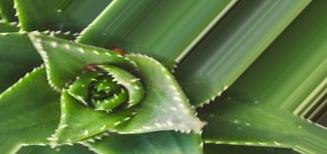

🤖 [Model]: Classified '/kaggle/input/plants-type-datasets/split_ttv_dataset_type_of_plants/Test_Set_Folder/aloevera/aug_0_2916.jpg' as: 'Aloe Vera'

🔍 [RAG]: Searching knowledge base for 'Aloe Vera'...
   - Found 3 relevant text chunks.

   📄 [Chunk 1]:
   Source: https://www.thespruce.com/grow-aloe-vera-1403153

   📄 [Chunk 2]:
   Source: https://www.thespruce.com/grow-aloe-vera-1403153

   📄 [Chunk 3]:
   Source: https://www.thespruce.com/grow-aloe-vera-1403153
🧠 [Agent]: Generating Augmented Care Card...

--- ✅ FINAL RAG OUTPUT (Aloe Vera) ---
{
  "common_name": "Aloe vera",
  "description": "Aloe vera is a succulent perennial known for its thick, fleshy leaves that contain a soothing gel often used for skin treatments.",
  "lighting": "Full, partial",
  "watering": "Water every 2-3 weeks, allowing the soil to dry out completely between waterings.",
  "temperature": "10\u00b0C - 30\u00b0C",
  "soil": "Sandy, well-draining soil",
  "fertilizer": "Feed with a balanced liquid fertilize

/tmp/ipython-input-1241976882.py:75: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  print(json.dumps(care_card.dict(), indent=2))


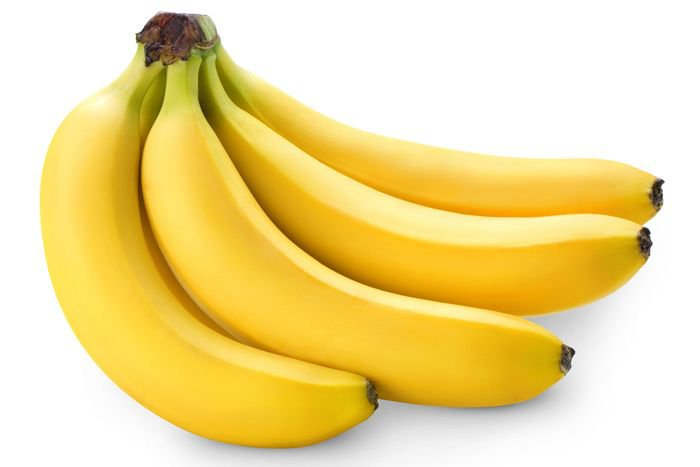

🤖 [Model]: Classified '/kaggle/input/plants-type-datasets/split_ttv_dataset_type_of_plants/Test_Set_Folder/banana/banana673.jpg' as: 'Banana'

🔍 [RAG]: Searching knowledge base for 'Banana'...
   - Found 3 relevant text chunks.

   📄 [Chunk 1]:
   Source: https://www.thespruce.com/banana-tree-growing-profile-3269353

   📄 [Chunk 2]:
   Source: https://www.thespruce.com/banana-tree-growing-profile-3269353

   📄 [Chunk 3]:
   Source: https://www.thespruce.com/banana-tree-growing-profile-3269353
🧠 [Agent]: Generating Augmented Care Card...

--- ✅ FINAL RAG OUTPUT (Banana) ---
{
  "common_name": "Banana tree, plantain tree",
  "description": "Banana trees are large herbaceous plants known for their fleshy stalks and large, bright green leaves. They produce showy flowers and elongated fruit.",
  "lighting": "Full sun to partial shade",
  "watering": "Water frequently to keep the soil evenly moist but not soggy",
  "temperature": "Hardiness Zones 9\u201311",
  "soil": "Loamy, well-drained so

/tmp/ipython-input-1241976882.py:75: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  print(json.dumps(care_card.dict(), indent=2))


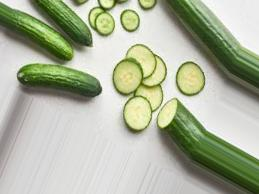

🤖 [Model]: Classified '/kaggle/input/plants-type-datasets/split_ttv_dataset_type_of_plants/Test_Set_Folder/cucumber/aug_0_3585.jpg' as: 'Cucumber'

🔍 [RAG]: Searching knowledge base for 'Cucumber'...
   - Found 3 relevant text chunks.

   📄 [Chunk 1]:
   Source: https://www.thespruce.com/cucumber-plant-growing-stages-7368730

   📄 [Chunk 2]:
   Source: https://www.thespruce.com/cucumber-plant-growing-stages-7368730

   📄 [Chunk 3]:
   Source: https://www.thespruce.com/cucumber-plant-growing-stages-7368730
🧠 [Agent]: Generating Augmented Care Card...

--- ✅ FINAL RAG OUTPUT (Cucumber) ---
{
  "common_name": "Cucumber",
  "description": "Cucumbers are fast-growing, vining plants that produce crisp, refreshing fruits commonly used in salads and pickling.",
  "lighting": "Full sun",
  "watering": "Water daily in hot weather, otherwise every other day, keeping soil moist but not wet.",
  "temperature": "18\u00b0C - 35\u00b0C (65\u00b0F - 95\u00b0F)",
  "soil": "Well-draining, nutrient-rich 

/tmp/ipython-input-1241976882.py:75: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  print(json.dumps(care_card.dict(), indent=2))


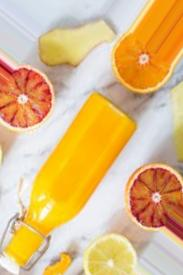

🤖 [Model]: Classified '/kaggle/input/plants-type-datasets/split_ttv_dataset_type_of_plants/Test_Set_Folder/ginger/aug_0_115.jpg' as: 'Ginger'

🔍 [RAG]: Searching knowledge base for 'Ginger'...
   - Found 3 relevant text chunks.

   📄 [Chunk 1]:
   Source: https://www.thespruce.com/flowering-ginger-plants-1315760

   📄 [Chunk 2]:
   Source: https://www.thespruce.com/flowering-ginger-plants-1315760

   📄 [Chunk 3]:
   Source: https://www.thespruce.com/flowering-ginger-plants-1315760
🧠 [Agent]: Generating Augmented Care Card...

--- ✅ FINAL RAG OUTPUT (Ginger) ---
{
  "common_name": "Ginger",
  "description": "Ginger plants are tropical perennials known for their aromatic rhizomes and vibrant flowers, thriving in warm, humid environments.",
  "lighting": "Filtered light or part-shade",
  "watering": "Water frequently during the growing season, approximately one inch per week; reduce in fall and winter.",
  "temperature": "Hardiness Zones 7-10 (USDA)",
  "soil": "Moist, well-draining, orga

/tmp/ipython-input-1241976882.py:75: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  print(json.dumps(care_card.dict(), indent=2))


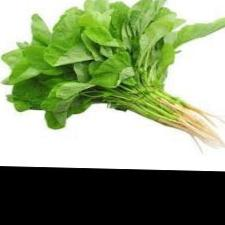

🤖 [Model]: Classified '/kaggle/input/plants-type-datasets/split_ttv_dataset_type_of_plants/Test_Set_Folder/spinach/aug_0_2800.jpg' as: 'Spinach'

🔍 [RAG]: Searching knowledge base for 'Spinach'...
   - Found 3 relevant text chunks.

   📄 [Chunk 1]:
   Source: https://www.thespruce.com/growing-spinach-1403448

   📄 [Chunk 2]:
   Source: https://www.thespruce.com/growing-spinach-1403448

   📄 [Chunk 3]:
   Source: https://www.thespruce.com/growing-spinach-1403448
🧠 [Agent]: Generating Augmented Care Card...

--- ✅ FINAL RAG OUTPUT (Spinach) ---
{
  "common_name": "Spinach",
  "description": "Spinach is an annual leafy green vegetable that grows best in cool weather, known for its smooth, medium to dark green leaves.",
  "lighting": "Full sun, partial sun",
  "watering": "Keep soil consistently moist but not waterlogged.",
  "temperature": "Cool weather; best in spring or fall.",
  "soil": "Loamy, moist, well-drained",
  "fertilizer": "Feed with a balanced fertilizer every 4-6 weeks durin

/tmp/ipython-input-1241976882.py:75: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  print(json.dumps(care_card.dict(), indent=2))


In [ ]:
import glob
import random
from IPython.display import Image, display

img_index = random.randint(0, 98)

if __name__ == "__main__":

    # 1. Load Vision Model
    model = load_model(
        CHECKPOINT_PATH,
        FineTuneEfficientNetB0,
        FineTuneLightningModule,
        NUM_CLASSES
    )

    # 2. Initialize RAG Chain
    rag_chain = create_rag_plant_care_pipeline()

    # 3. Setup Retriever tool
    retriever = vector_store.as_retriever(search_kwargs={"k": 3})

    BASE_TEST_PATH = "/kaggle/input/plants-type-datasets/split_ttv_dataset_type_of_plants/Test_Set_Folder/"

    # Images to test (Filtering for ones we scraped data for)
    supported_plants = ["aloevera", "banana", "cucumber", "ginger", "spinach"]

    # Find test images
    test_image_paths = []
    for plant_class in supported_plants:
        class_folder = os.path.join(BASE_TEST_PATH, plant_class)
        image_files = glob.glob(os.path.join(class_folder, "*.jpg"))
        if image_files:
            test_image_paths.append(image_files[img_index])

    # --- RUN LOOP ---
    if model and test_image_paths:
        for image_path in test_image_paths:
            print("\n" + "="*70)
            print(f"--- 🚀 Processing: {image_path} ---")

            # A. Display
            display(Image(filename=image_path))

            # B. Vision Classification
            plant_label = get_plant_label_from_image(
                image_path, model, CLASS_NAMES, inference_transform
            )

            if plant_label != "Error":
                # Lowercase label for matching our scraped data keys if needed,

                print(f"\n🔍 [RAG]: Searching knowledge base for '{plant_label}'...")

                # C. RETRIEVAL STEP
                retrieved_docs = retriever.invoke(plant_label)
                context_text = "\n\n".join([d.page_content for d in retrieved_docs])

                print(f"   - Found {len(retrieved_docs)} relevant text chunks.")

                for i, doc in enumerate(retrieved_docs):
                    print(f"\n   📄 [Chunk {i+1}]:")
                    print(f"   Source: {doc.metadata.get('source', 'Unknown')}")
                    # print(f"   Content: {doc.page_content[:200]}...") # Print first 200 chars to avoid clutter

                # D. GENERATION STEP
                print(f"🧠 [Agent]: Generating Augmented Care Card...")
                care_card = rag_chain.invoke({
                    "plant_name": plant_label,
                    "context": context_text
                })

                print("\n" + "="*50)
                print(f"--- ✅ FINAL RAG OUTPUT ({plant_label}) ---")
                print(json.dumps(care_card.dict(), indent=2))
                print("="*50)